In [2]:
import os, gc, sys, warnings

from glob import glob

import importlib

sys.path.append(r'/Users/xpintm/Library/CloudStorage/OneDrive-Personal/Documentos/Python/MAPJ-tools/')
import MAPJtools as mapj
#%matplotlib widget
from tqdm import tqdm
import numpy as np
import pandas as pd

import xarray as xr
from scipy.interpolate import interp1d
from scipy.optimize import fmin

import gsw
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl
import matplotlib.pyplot as plt
import cmocean.cm as cmo
sys.path.append(r'/Users/xpintm/Library/CloudStorage/OneDrive-Personal/Documentos/Python/gliderad2cpV2/')

from gliderad2cp import process_currents, process_shear, process_bias, tools

import seaborn as sns
sns.set_theme(    rc={
         'axes.axisbelow': False,
         'axes.edgecolor': 'Black',
         'axes.facecolor': 'white',
         'axes.grid': False,
         'axes.labelcolor': 'k',
            
         'axes.spines.right': True,
         'axes.spines.top': True,
         'figure.facecolor': 'white',
         'lines.solid_capstyle': 'round',
         'patch.edgecolor': 'k',
         'patch.force_edgecolor': False,
         'text.color': 'k',
         'xtick.bottom': True,
         'xtick.color': 'k',
         'xtick.direction': 'out',
         'xtick.top': False,
         'ytick.color': 'k',
         'ytick.direction': 'out',
         'ytick.left': True,
         'ytick.right': False},
         font_scale=2.1)

import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import shapefile
from cartopy.io.shapereader import Reader
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec


In [3]:
def nearest_indices(time_array, target_times):
    idx = np.searchsorted(time_array, target_times)
    idx = np.clip(idx, 1, len(time_array)-1)
    left = time_array[idx-1]
    right = time_array[idx]
    # Choose closer one
    idx -= (target_times - left) < (right - target_times)
    return idx
def extract_nearest_timeseries(ds,d57):
    """
    Extract a time series of nearest grid point data from an xarray.Dataset.
    
    Parameters:
        ds (xarray.Dataset): The input dataset with 'time', 'latitude', 'longitude' coordinates.
        lonD (array-like): Array of longitudes corresponding to each time step.
        latD (array-like): Array of latitudes corresponding to each time step.
        
    Returns:
        xarray.Dataset: A new dataset with dimension 'time' containing data variables
                        at the nearest (longitude, latitude) point for each time.
    """
    # List to store the subset for each time step
    data_list = []
    idx__ = nearest_indices(ds.time.values,d57.time_profile.values)
    idx__ = np.unique(idx__)
    #ds.isel(time=idx__).time.values
    idx_ = nearest_indices(d57.time_profile.values, ds.time)
    idx_=np.unique(idx_)
    d57.time_profile[idx_]
    latD=d57.latitude[:,idx_].mean(axis=0).values
    lonD=d57.longitude[:,idx_].mean(axis=0).values
    # # Ensure the number of positions matches the time dimension length
    # if len(lonD) != ds.dims['time'] or len(latD) != ds.dims['time']:
    #     raise ValueError("Length of lonD and latD must equal the length of the 'time' dimension in the dataset.")

    # Loop over each time step
    for i, time_value in enumerate(d57.time_profile[idx_].values):
        #print(time_value)
        # Select the data at the nearest (lon, lat) for this time step
        subset = ds.sel(
            time=time_value,
            longitude=lonD[i],
            latitude=latD[i],
            method='nearest'
        )
        data_list.append(subset)

    # Concatenate along the time dimension
    ds_subset = xr.concat(data_list, dim="time")
    
    # Optionally, reassign the original time coordinate (if needed)
    ds_subset = ds_subset.assign_coords(time=d57.time_profile[idx_].values)
    return ds_subset

def plot_map(ax,times,tidx):
    """
    Plot land, coastline, bathymetry, and reference lines on the given axes.

    Parameters
    ----------
    ax : matplotlib Axes
        Axes object where the map will be plotted.
    """
    # times to plot
    #times = np.array(['2024-11-10','2024-11-25','2024-12-07','2024-12-25','2025-01-15','2025-02-03'], dtype='datetime64[ns]')
    idx_57 = nearest_indices(d57.time_profile.values, times)#.resample(time_profile='1D').mean().values
    idx_70 = nearest_indices(d70.time_profile.values, times)#.resample(time_profile='1D').mean().values
    idx_GLO = nearest_indices(GLO.time.values, times)
    gebco= xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Bathymetry/gebco_2023_n30.0_s-5.0_w30.0_e80.0.nc')
    bath_levels = [-2000, -1000, -100]
    # Load GEBCO
    elevation = gebco.elevation
    lon = gebco.lon
    lat = gebco.lat
    # Subset
    lon_min, lon_max = 56.25, 59.25
    lat_min, lat_max = 23, 26
    elev_sub = elevation.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    lon2d, lat2d = np.meshgrid(elev_sub.lon, elev_sub.lat)
    # Glo lims
    col_min=np.percentile(GLO.adt.min().values, 5)
    col_max=np.percentile(GLO.adt.max().values, 95)
    #tidx=5
    #fig,ax = plt.subplots(figsize=(4.5, 4.5), dpi=200)
    #ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    # Grid
    #gl = ax.grid(linewidth=0.3, color='gray',linestyle='--', alpha=1,zorder=5)
    # Land
    ax.contourf(lon2d, lat2d, elev_sub > 0, levels=[0.5, 1.5], colors='lightgray', zorder=5,alpha=1)
    # Coastline
    ax.contour(lon2d, lat2d, elev_sub, levels=[0], colors='k', linewidths=0.7, zorder=6)
    # Bathymetry
    elev_masked = np.ma.masked_invalid(elev_sub.values)
    bath = ax.contour(lon2d, lat2d, elev_masked, levels=bath_levels,colors='w', linestyles='--', linewidths=0.7, zorder=3)
    ax.plot([coords["M0"][1], coords["M2"][1]], [coords["M0"][0], coords["M2"][0]],color='k', linestyle='-', linewidth=2, zorder=8)  # Vertical line (M0 ↔ M2)
    ax.plot([coords["NW"][1], coords["SE"][1]], [coords["NW"][0], coords["SE"][0]],color='k', linestyle='-', linewidth=2, zorder=8)  # Horizontal line (NW ↔ SE)
    ps=ax.contourf(GLO.longitude, GLO.latitude, GLO.vorticity_local[idx_GLO[tidx],:,:],levels=500, cmap='bwr',zorder=1,vmin=-3,vmax=3)
    ax.contour(GLO.longitude, GLO.latitude, GLO.vorticity_local[idx_GLO[tidx],:,:],linestyles='-.', colors='k', linewidths=1,alpha=1, levels=np.array([0]),zorder=8)# 0 vorticity
    ax.contour(GLO.longitude, GLO.latitude, GLO.adt[idx_GLO[tidx],:,:],levels=np.linspace(col_min, col_max, 50),colors='k',linewidths=0.3,zorder=4)
    ax.quiver(GLO.longitude, GLO.latitude,GLO.ugos[idx_GLO[tidx],:,:], GLO.vgos[idx_GLO[tidx],:,:],scale=2, color='k',alpha=0.7,scale_units='inches', angles='uv',zorder=4)
    ax.set_ylim(lat_min, lat_max)
    ax.set_xlim(lon_min, lon_max)
    ax.plot(d57.longitude[:,idx_57[tidx]].mean().values, d57.latitude[:,idx_57[tidx]].mean().values,marker='.', color='m', markersize=4,zorder=9)
    ax.plot(d70.longitude[:,idx_70[tidx]].mean().values, d70.latitude[:,idx_70[tidx]].mean().values,marker='d', color='m', markersize=4,zorder=9)
    ax.text(56.5,23.25,times[tidx].astype('datetime64[D]').astype(str), fontsize=20,zorder=7);

def compute_vorticity(ds):
    # Earth's radius in meters
    R = 6371000  # meters
    # Compute grid spacing in meters
    dlat = (ds.latitude.values[1] - ds.latitude.values[0]) * (R * np.pi / 180)  # dy
    dlon = (ds.longitude.values[1] - ds.longitude.values[0]) * (R * np.pi / 180) * np.cos(np.deg2rad(ds.latitude.values[:, np.newaxis]))  # dx
    
    # Reshape dlat and dlon to align with the dataset dimensions
    dlat_3d = np.broadcast_to(dlat, (ds.time.size, ds.latitude.size, ds.longitude.size))  # (time, lat, lon)
    dlon_3d = np.broadcast_to(dlon, (ds.time.size, ds.latitude.size, ds.longitude.size))  # (time, lat, lon)

    # Compute gradients using xarray's differentiate method
    dv_dx = ds.vgos.differentiate("longitude") / dlon_3d
    du_dy = ds.ugos.differentiate("latitude") / dlat_3d
    
    # Compute vorticity
    vorticity = dv_dx - du_dy
    
    # Assign to dataset using .data to extract raw values
    ds['vorticity'] = (('time', 'latitude', 'longitude'), vorticity.data)
    # Compute Coriolis parameter f = 2 * Omega * sin(latitude)
    Omega = 7.2921e-5  # Earth's rotation rate in rad/s
    f = 2 * Omega * np.sin(np.deg2rad(ds.latitude.values[:, np.newaxis]))
    
    # Reshape f to match dataset dimensions
    f_3d = np.broadcast_to(f, (ds.time.size, ds.latitude.size, ds.longitude.size))
    
    # Assign Coriolis parameter to dataset
    ds['f'] = (('time', 'latitude', 'longitude'), f_3d)
    ds['vorticity_local'] = (('time', 'latitude', 'longitude'), vorticity.data/f_3d)
    return ds

def viscosity(s, t, rho):
    """
    Compute molecular and kinematic viscosity of seawater.

    Parameters:
    -----------
    s : Salinity [g/kg]
    t : Temperature [°C] (in-situ)
    rho : Density [kg/m^3]

    Returns:
    --------
    nu : Kinematic viscosity [m²/s]
    mu : Dynamic (molecular) viscosity [Pa·s]
    """
    # Coefficients from Millero (1974) / Peters & Siedler
    a0 = 2.5116e-6
    a1 = 1.2199e-6
    b0 = 1.4342e-6
    b1 = 1.8267e-8
    c0 = 1.002e-3
    d0 = 1.1709
    d1 = 1.827e-3
    d2 = 89.93

    # Molecular viscosity at salinity = 0
    mu0 = c0 * 10 ** ((d0 * (20 - t) - d1 * (t - 20) ** 2) / (t + d2))

    # Dynamic viscosity at salinity = s
    rs = rho * s
    mu = mu0 * (1 + (a0 + a1 * t) * np.sqrt(rs) + (b0 + b1 * t) * rs)

    # Kinematic viscosity
    nu = mu / rho

    return nu, mu
def load_fast(uid_, uid_code, varname):
    """
    Load the fast parquet file corresponding to uid_code
    and return P_fast plus the requested variable(s).

    Parameters
    ----------
    uid_ : xarray.Dataset
        The uid_files.nc opened with xr.open_dataset
    uid_code : int
        Numeric identifier of the file
    varname : str or list of str
        Variable(s) to load in addition to P_fast

    Returns
    -------
    ds : xarray.Dataset
        Contains P_fast and requested variable(s)
    """
    if isinstance(varname, str):
        varname = [varname]

    # Find row for this uid_code
    matches = (uid_['uid_code'].values == uid_code).nonzero()[0]
    if len(matches) == 0:
        raise ValueError(f"uid_code {uid_code} not found in uid_files.nc")
    row = int(matches[0])

    source_dir  = str(uid_['source_dir'].values[row])
    source_file = str(uid_['source_file'].values[row])

    # Build fast filename
    fast_file = source_file.replace('.pqt', '_fast.pqt')
    fast_path = os.path.join('/Volumes/WD_BLACK/2024_OMAN', source_dir, fast_file)

    if not os.path.exists(fast_path):
        raise FileNotFoundError(f"Fast file not found: {fast_path}")

    # Always include P_fast
    cols = ['P_fast'] + varname
    df = pd.read_parquet(fast_path, columns=cols)

    # Convert to xarray Dataset
    ds = xr.Dataset.from_dataframe(df)

    # Add uid_code as a coordinate
    ds = ds.assign_coords(uid_code=uid_code)

    return ds


In [4]:
from scipy import integrate
from scipy import stats, interpolate
from scipy.integrate import cumulative_trapezoid
import numpy as np
import time
# ----------------------
# Saturation pressure
# ----------------------
def SW_Psat(T, uT, S, uS):
    """
    Saturation (vapor) pressure of seawater [Pa]
    """
    # --- temperature units ---
    if uT.lower() == 'k':
        T = T - 273.15
    elif uT.lower() == 'f':
        T = 5/9 * (T - 32)
    elif uT.lower() == 'r':
        T = 5/9 * (T - 491.67)
    elif uT.lower() != 'c':
        raise ValueError("Unrecognized temperature unit")

    # --- salinity units ---
    if uS.lower() == 'ppm':
        S = S / 1000
    elif uS.lower() == 'w':
        S = S * 1000
    elif uS.lower() == '%':
        S = S * 10
    elif uS.lower() != 'ppt':
        raise ValueError("Unrecognized salinity unit")

    # Convert to Kelvin
    T = T + 273.15

    a = np.array([
        -5.8002206E+03,
         1.3914993E+00,
        -4.8640239E-02,
         4.1764768E-05,
        -1.4452093E-08,
         6.5459673E+00
    ])

    Pv_w = np.exp((a[0]/T) + a[1] + a[2]*T + a[3]*T**2 + a[4]*T**3 + a[5]*np.log(T))

    b = np.array([-4.5818e-4, -2.0443e-6])

    return Pv_w * np.exp(b[0]*S + b[1]*S**2)


# ----------------------
# Specific heat capacity
# ----------------------
def SW_SpcHeat(T, uT, S, uS, P, uP):
    """
    Specific heat at constant pressure [J/kg-K]
    """
    # --- units ---
    if uT.lower() == 'k':  T = T - 273.15
    elif uT.lower() == 'f': T = 5/9*(T - 32)
    elif uT.lower() == 'r': T = 5/9*(T - 491.67)
    elif uT.lower() != 'c': raise ValueError("Bad T unit")

    if uS.lower() == 'ppm': S = S/1000
    elif uS.lower() == 'w': S = S*1000
    elif uS.lower() == '%': S = S*10
    elif uS.lower() != 'ppt': raise ValueError("Bad S unit")

    if uP.lower() == 'bar':   P = P/10
    elif uP.lower() == 'kpa': P = P/1000
    elif uP.lower() == 'pa':  P = P/1e6
    elif uP.lower() != 'mpa': raise ValueError("Bad P unit")

    Psat = SW_Psat(T, 'C', S, 'ppt') / 1e6
    P0 = np.where(T < 100, 0.101325, Psat)

    T68 = 1.00024*(T+273.15)

    A = 5.328 - 9.76e-2*S + 4.04e-4*S**2
    B = -6.913e-3 + 7.351e-4*S - 3.15e-6*S**2
    C = 9.6e-6 - 1.927e-6*S + 8.23e-9*S**2
    D = 2.5e-9 + 1.666e-9*S - 7.125e-12*S**2
    cp0 = 1000*(A + B*T68 + C*T68**2 + D*T68**3)

    c1,c2,c3,c4,c5,c6,c7,c8 = -3.1118,0.0157,5.1014e-5,-1.0302e-6,0.0107,-3.9716e-5,3.2088e-8,1.0119e-9
    cpP = (P - P0)*(c1 + c2*T + c3*T**2 + c4*T**3 + S*(c5 + c6*T + c7*T**2 + c8*T**3))

    return cp0 + cpP


# ----------------------
# Density
# ----------------------
def SW_Density(T, uT, S, uS, P, uP):
    """
    Density of seawater [kg/m^3]
    """
    if uT.lower() == 'k':  T = T - 273.15
    elif uT.lower() == 'f': T = 5/9*(T - 32)
    elif uT.lower() == 'r': T = 5/9*(T - 491.67)
    elif uT.lower() != 'c': raise ValueError("Bad T unit")

    if uS.lower() == 'ppm': S = S/1000
    elif uS.lower() == 'w': S = S*1000
    elif uS.lower() == '%': S = S*10
    elif uS.lower() != 'ppt': raise ValueError("Bad S unit")

    if uP.lower() == 'bar':   P = P/10
    elif uP.lower() == 'kpa': P = P/1000
    elif uP.lower() == 'pa':  P = P/1e6
    elif uP.lower() != 'mpa': raise ValueError("Bad P unit")

    Psat = SW_Psat(T, 'C', S, 'ppt')/1e6
    P0 = np.where(T < 100, 0.101325, Psat)

    s = S/1000
    a = [9.9992293295E+02, 2.0341179217E-02, -6.1624591598E-03, 2.2614664708E-05, -4.6570659168E-08]
    b = [8.0200240891E+02, -2.0005183488E+00, 1.6771024982E-02, -3.0600536746E-05, -1.6132224742E-05]

    rho_w = a[0] + a[1]*T + a[2]*T**2 + a[3]*T**3 + a[4]*T**4
    D_rho = b[0]*s + b[1]*s*T + b[2]*s*T**2 + b[3]*s*T**3 + b[4]*s**2*T**2
    rho0 = rho_w + D_rho

    c = [5.0792e-04, -3.4168e-06, 5.6931e-08, -3.7263e-10, 1.4465e-12, -1.7058e-15,
         -1.3389e-06, 4.8603e-09, -6.8039e-13]
    d = [-1.1077e-06, 5.5584e-09, -4.2539e-11, 8.3702e-09]

    kT = (c[0] + c[1]*T + c[2]*T**2 + c[3]*T**3 + c[4]*T**4 + c[5]*T**5
          + P*(c[6] + c[7]*T + c[8]*T**3)
          + S*(d[0] + d[1]*T + d[2]*T**2 + d[3]*P))

    F_P = np.exp((P-P0)*(c[0] + c[1]*T + c[2]*T**2 + c[3]*T**3 + c[4]*T**4 + c[5]*T**5 + S*(d[0] + d[1]*T + d[2]*T**2))
                 + 0.5*(P**2-P0**2)*(c[6] + c[7]*T + c[8]*T**3 + d[3]*S))

    return rho0 * F_P


# ----------------------
# Thermal conductivity
# ----------------------
def SW_Conductivity(T, uT, S, uS):
    """
    Thermal conductivity [W/m-K]
    """
    if uT.lower() == 'k':  T = T - 273.15
    elif uT.lower() == 'f': T = 5/9*(T - 32)
    elif uT.lower() == 'r': T = 5/9*(T - 491.67)
    elif uT.lower() != 'c': raise ValueError("Bad T unit")

    if uS.lower() == 'ppm': S = S/1000
    elif uS.lower() == 'w': S = S*1000
    elif uS.lower() == '%': S = S*10
    elif uS.lower() != 'ppt': raise ValueError("Bad S unit")

    T68 = 1.00024*T
    S = S / 1.00472

    return 10**(np.log10(240+0.0002*S)
                + 0.434*(2.3 - (343.5+0.037*S)/(T68+273.15))
                * (1 - (T68+273.15)/(647.3+0.03*S))**(1/3)
                - 3)


# ----------------------
# Thermal diffusivity
# ----------------------
def SW_Diffusivity(T, uT, S, uS):
    """
    Thermal diffusivity [m^2/s]
    """
    P0 = SW_Psat(T,'C',S,'ppt')/1e6
    P0 = np.where(T < 100, 0.101325, P0)

    cp  = SW_SpcHeat(T, uT, S, uS, P0, 'MPa')
    rho = SW_Density(T, uT, S, uS, P0, 'MPa')
    k   = SW_Conductivity(T, uT, S, uS)

    return k / (rho * cp)
# ----------------------
# Haline diffusivity
# ----------------------
def SW_kappa_S(T):
    kappa_S = 1e-9*(0.7+0.036*T)
    return kappa_S
def SW_Viscosity(T, uT, S, uS):
    """
    Dynamic viscosity of seawater [kg/m·s] (Pa·s).
    Sharqawy et al. (2010), valid for 0 < T < 180 °C, 0 < S < 150 g/kg.
    """

    # --- temperature units ---
    if uT.lower() == 'k':
        T = T - 273.15
    elif uT.lower() == 'f':
        T = 5/9 * (T - 32)
    elif uT.lower() == 'r':
        T = 5/9 * (T - 491.67)
    elif uT.lower() != 'c':
        raise ValueError("Unrecognized temperature unit")

    # --- salinity units ---
    if uS.lower() == 'ppm':
        S = S / 1000
    elif uS.lower() == 'w':
        S = S * 1000
    elif uS.lower() == '%':
        S = S * 10
    elif uS.lower() != 'ppt':
        raise ValueError("Unrecognized salinity unit")

    # --- check ranges (warn only) ---
    if np.any((T < 0) | (T > 180)):
        print("Warning: Temperature out of range for SW_Viscosity (0<T<180 °C)")
    if np.any((S < 0) | (S > 150)):
        print("Warning: Salinity out of range for SW_Viscosity (0<S<150 g/kg)")

    # convert salinity to kg/kg
    S = S / 1000.0

    # coefficients
    a = np.array([
        1.5700386464E-01,
        6.4992620050E+01,
       -9.1296496657E+01,
        4.2844324477E-05,
        1.5409136040E+00,
        1.9981117208E-02,
       -9.5203865864E-05,
        7.9739318223E+00,
       -7.5614568881E-02,
        4.7237011074E-04
    ])

    # pure water viscosity
    mu_w = a[3] + 1.0 / (a[0]*(T + a[1])**2 + a[2])

    # salinity corrections
    A = a[4] + a[5]*T + a[6]*T**2
    B = a[7] + a[8]*T + a[9]*T**2

    mu = mu_w * (1 + A*S + B*S**2)
    return mu
def SW_Kviscosity(T, uT, S, uS):
    """
    Kinematic viscosity of seawater [m^2/s]
    Based on Sharqawy et al. (2010).
    """

    # Saturation pressure [MPa]
    P0 = SW_Psat(T, 'C', S, 'ppt') / 1e6
    P0 = np.where(T < 100, 0.101325, P0)

    uP = 'MPa'

    mu  = SW_Viscosity(T, uT, S, uS)           # dynamic viscosity [Pa·s]
    rho = SW_Density(T, uT, S, uS, P0, uP)     # density [kg/m^3]

    nu = mu / rho                              # kinematic viscosity [m^2/s]
    return nu


In [5]:
# Default settings for all figures
# plt.rcParams.update({
#     "figure.figsize": (4.5, 4.5),         # inches — suitable for 1-column in Word
#     "figure.dpi": 100,                    # high resolution for export
#     "font.size": 12,                      # base font size
#     "axes.titlesize": 11,                 # title font
#     "axes.labelsize": 10,                 # axis labels
#     "xtick.labelsize": 10,
#     "ytick.labelsize": 10,
#     "legend.fontsize": 10,
#     "axes.linewidth": 0.8,
#     "lines.linewidth": 1,
#     "xtick.direction": "out",
#     "ytick.direction": "out",
#     "xtick.major.size": 3,
#     "ytick.major.size": 3,
#     "savefig.dpi": 600,                   # savefig resolution
#     "savefig.bbox": "tight",
#     "font.family": "sans-serif",
#     "font.sans-serif": ["Arial"]         # Word-compatible font
# })

# Colormaps

In [6]:
cmap_name = 'flags'
colors=[(1,1,1),(0,0.447,0.741),(0.850,0.325,0.098),(0.929,0.694,0.125),(0.635,0.078,0.184),(0.466,0.674,0.188)]
cmap_flag = LinearSegmentedColormap.from_list(cmap_name, colors, N=6)
colors=[(1,1,1),(0,0.447,0.741),(0.929,0.694,0.125)]
cmap_Rrho = LinearSegmentedColormap.from_list(cmap_name, colors, N=3)

cmap_epsi=plt.get_cmap('cmo.thermal',6)
# Define discrete color map for Turner angle interpretation
cmap_name = 'Tu_regimes'
colors = [
    (0.0, 0.0, 0.5),     # Strong convective diffusion (dark blue)
    (0.4, 0.7, 1.0),     # Weak convective diffusion (light blue)
    (1.0, 1.0, 1.0),     # Double stable (white)
    (1.0, 0.6, 0.0),     # Weak salt fingering (orange)
    (0.8, 0.0, 0.0)      # Strong salt fingering (red)
]
# Construct colormap with 5 bins matching the regimes
cmap_Tu = LinearSegmentedColormap.from_list(cmap_name, colors, N=5)

# Load Glider data

In [7]:
#d57=xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/SEA057_gridded_high_res.nc')
#d57 = d57.swap_dims({'profile_index': 'time_profile'})#.drop_vars('profile_index')

In [8]:
# vars_to_drop = [
#     "declination",
#     "nav_resource",
#     "nav_state",
#     "ad2cp_pressure",
#     "ad2cp_time",
#     "heading",
#     "pitch",
#     "roll",
#     "security_level",
#     "internal_temperature",
#     "internal_pressure",
#     "desired_heading",
#     "ballast_cmd",
#     "ballast_pos",
#     "linear_cmd",
#     "linear_pos",
#     "angular_cmd",
#     "angular_pos",
#     "voltage",
#     "dead_reckoning",
#     "nav_resourse",
#     "phycoerythrin",
#     "phycoerythrin_raw",
#     "ad2cp_heading",
#     "ad2cp_pitch",
#     "ad2cp_roll",
#     "ad2cp_beam1_cell_number1",
#     "ad2cp_beam2_cell_number2",
#     "ad2cp_beam3_cell_number2",
#     "ad2cp_beam4_cell_number2",
#     "tke_dissipation_shear_1",
#     "tke_dissipation_shear_2",
#     "distance_over_ground",
#     "profile_direction",
#     "sound_speed",
#     "spiciness",
#     "paticulate_backscatter",
#     "segment_fast1",
#     "segment_fast2",
#     "segment_slow1",
#     "segment_slow2",
#     "epsilon_param",
#     "time_in_bin",
#     "heading_N",
#     "heading_E",
#     "shear_E_mean",
#     "shear_E_median",
#     "shear_E_stddev",
#     "shear_E_count",
#     "shear_N_mean",
#     "shear_N_median",
#     "shear_N_stddev",
#     "shear_N_count",
# ]

# d57 = d57.drop_vars(vars_to_drop, errors="ignore")

In [9]:
# attrs_to_add = {
#     "long_name": "",
#     "standard_name": "",
#     "units": "",
#     "comment": "",
#     "accuracy": "",
#     "precision": "",
#     "platform": "",
#     "resolution": "",
# }

# for var in d57.variables:
#     for key, value in attrs_to_add.items():
#         d57[var].attrs.setdefault(key, value)

In [10]:
# attrs_from_file = {}
# current_var = None

# with open("d57_variable_attributes.txt", "r") as f:
#     for line in f:
#         line = line.strip()

#         # Skip empty lines
#         if not line:
#             continue

#         # Variable header, e.g. "## dive_num"
#         if line.startswith("##"):
#             current_var = line.replace("##", "", 1).strip()
#             attrs_from_file[current_var] = {}
#             continue

#         # Attribute line
#         if ":" in line and current_var is not None:
#             key, value = line.split(":", 1)
#             attrs_from_file[current_var][key.strip()] = value.strip()


# # Update d57 attributes
# for var, attrs in attrs_from_file.items():
#     if var in d57.variables:
#         d57[var].attrs.update(attrs)
#     else:
#         print(f"Variable not found in d57: {var}")

In [11]:

# # Define coordinates
# coords = {
#     "M2": (24.29972, 57.67194),
#     "NW": (24.26333, 57.51667),
#     "SE": (24.16500, 57.70000),
#     "M0": (24.13500, 57.55444),
#     "VM": (24.21194, 57.61222)
# }
# a=500

In [12]:
# d57["time"].attrs.pop("units", None)
# d57["time_profile"].attrs.pop("units", None)

In [13]:
#d57.to_netcdf('/Volumes/WD_BLACK/2024_OMAN/Data4Zenodo/SEA057_gridded_high_res.nc')

In [14]:
d57=xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Data4Zenodo/SEA057_gridded_high_res.nc')

# Load SSH

In [15]:
GLO=xr.open_dataset('/Volumes/WD_BLACK/2024_OMAN/Data_download/GLO/AVISO/cmems_obs-sl_glo_phy-ssh_nrt_allsat-l4-duacs-0.125deg_P1D_1755079926474.nc')
# Compute vorticity and add it to the dataset
GLO = compute_vorticity(GLO)

In [16]:
spi1=gsw.spiciness0(d57.abs_salinity, d57.cons_temperature)
spi2=gsw.alpha(d57.abs_salinity,d57.cons_temperature,d57.pressure)*d57.cons_temperature+gsw.beta(d57.abs_salinity,d57.cons_temperature,d57.pressure)*d57.abs_salinity
spi3=gsw.spiciness0(d57.abs_salinity, d57.cons_temperature)*1.03-24.5/1000

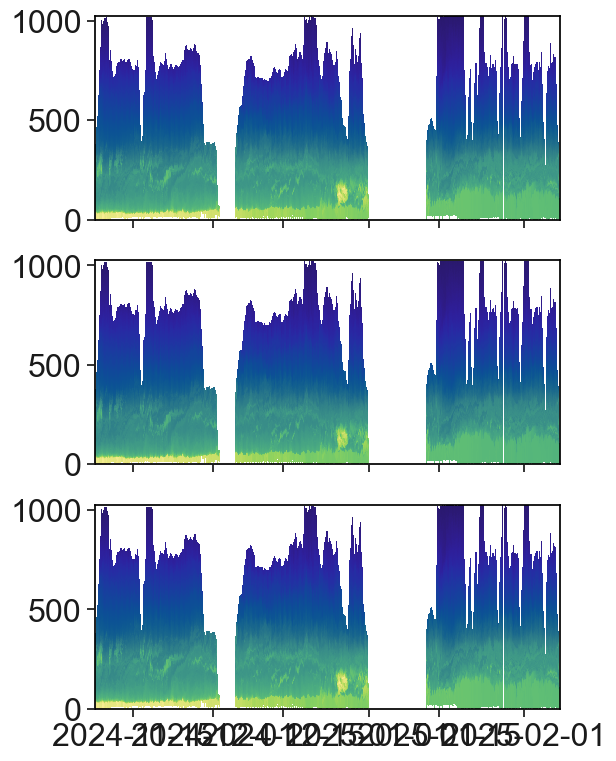

In [17]:
fig,axes=plt.subplots(3,1, figsize=(6, 9), dpi=100, sharex=True)
axes[0].pcolormesh(d57.time_profile,d57.depth,spi1,cmap='cmo.haline', shading='auto')
axes[1].pcolormesh(d57.time_profile,d57.depth,spi2,cmap='cmo.haline', shading='auto')
axes[2].pcolormesh(d57.time_profile,d57.depth,spi3,cmap='cmo.haline', shading='auto')

In [18]:
d57 = mapj.compute_N2(d57)
d57 = mapj.compute_Tu(d57)
d57["spiciness"] = (["depth", "time_profile"], mapj.spiciness_(d57)) #using GSW
#d57["spiciness"] = (["depth", "time_profile"], spi2.values)  #using linearized equation
d57 = mapj.compute_Ri(d57)

nu,mu=viscosity(d57.abs_salinity, d57.cons_temperature, d57.potential_density)
nu2=SW_Kviscosity(d57.temperature, 'C', d57.salinity, 'ppt')


In [19]:
d57.time_profile[10:15]

<xarray.DataArray 'time_profile' (time_profile: 5)> Size: 40B
array(['2024-11-08T00:46:40.000000000', '2024-11-08T03:51:51.000000000',
       '2024-11-08T07:10:15.000000000', '2024-11-08T10:49:53.000000000',
       '2024-11-08T15:02:02.000000000'], dtype='datetime64[ns]')
Coordinates:
    profile_index  (time_profile) float64 40B ...
  * time_profile   (time_profile) datetime64[ns] 40B 2024-11-08T00:46:40 ... ...
Attributes:
    long_name:      Profile time
    standard_name:  time
    comment:        Representative time associated with each glider profile
    accuracy:       
    precision:      
    platform:       SeaExplorer glider
    resolution:

(500.0, 0.0)

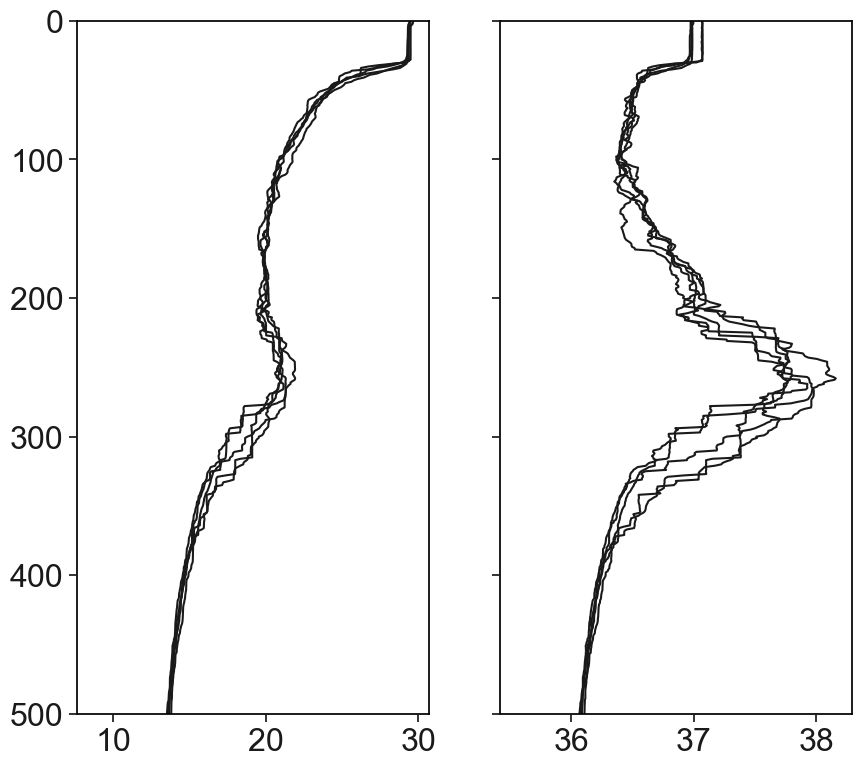

In [20]:
fig,ax=plt.subplots(1,2, figsize=(10, 9), dpi=100,sharey=True)
_=ax[0].plot(d57.cons_temperature[:,10:15],d57.depth, 'k')
_=ax[1].plot(d57.abs_salinity[:,10:15],d57.depth, 'k')
ax[0].set_ylim(500,0)
ax[1].set_ylim(500,0)


In [21]:
colors=[cmo.deep.resampled(4)(0)[:3],cmo.matter.resampled(4)(2)[:3],cmo.deep.resampled(4)(1)[:3],cmo.deep.resampled(4)(2)[:3]]
#colors=[cmo.matter.resampled(4)(1)[:3],cmo.matter.resampled(4)(2)[:3],cmo.deep.resampled(4)(0)[:3],cmo.deep.resampled(4)(2)[:3],cmo.deep.resampled(4)(1)[:3],cmo.gray.resampled(4)(0)[:3]]
cmap_Rrho = LinearSegmentedColormap.from_list(cmap_name, colors, N=4)

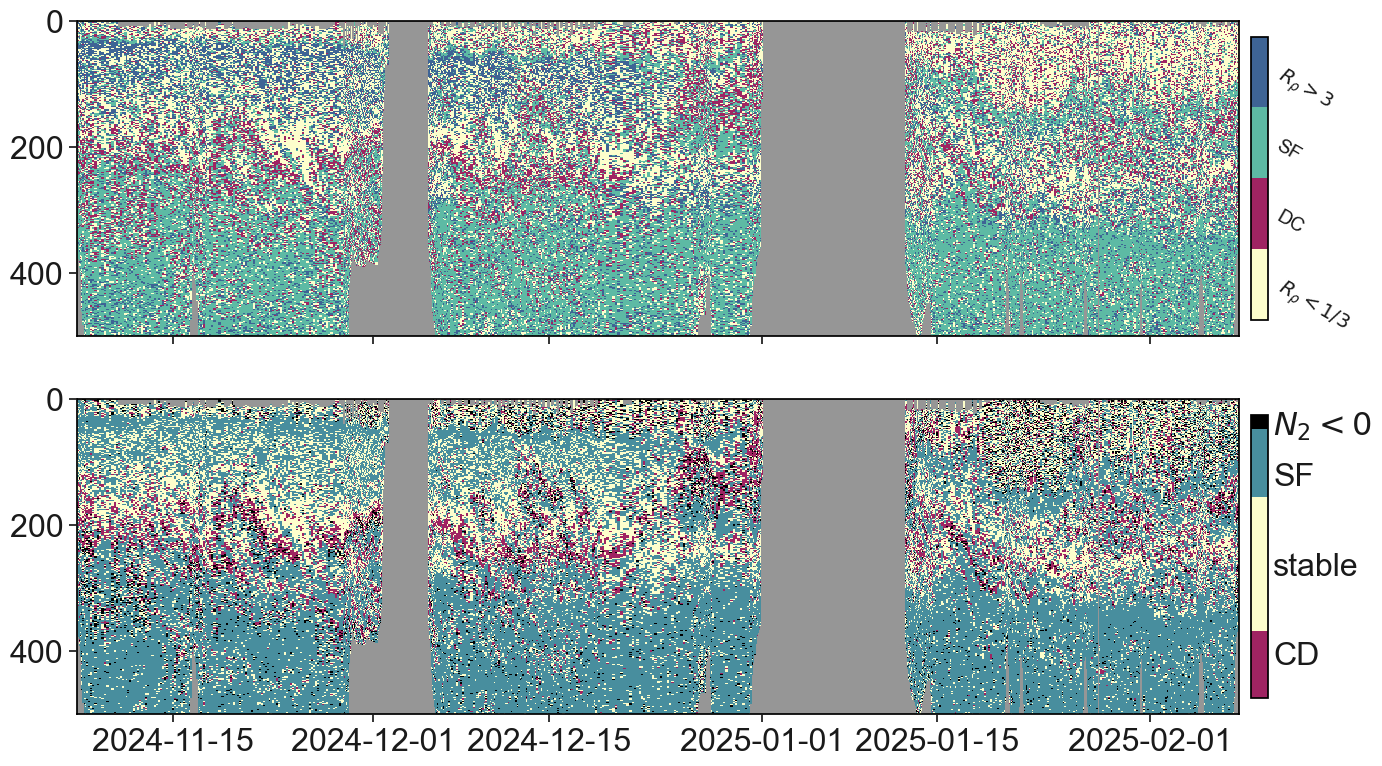

In [22]:
fig,axs=plt.subplots(2,1, figsize=(15, 9), dpi=100, sharex=True)
mapj.plot_density_ratio(d57.Rrho,limit=3,limit_DC=1/3, ax=axs[0], cmap=cmap_Rrho)
# mesh=axs[0].pcolormesh(d57.time_profile,d57.depth, d57.Rrho, vmin=-1, vmax=2, cmap=cmap_Rrho, shading='auto')
# cax = axs[0].inset_axes([1.01, 0.05, 0.01, 0.9])
# cbar = fig.colorbar(mesh, cax=cax, label=r'$R\rho$', extend='both', pad=0.02)
axs[0].set_ylim(500,0)
axs[0].set_facecolor(np.array([1, 1, 1]) / 1.7)
mapj.plot_turner_angle(d57.Tu,ax=axs[1],colc=2)
axs[1].set_ylim(500,0)
axs[1].set_facecolor(np.array([1, 1, 1]) / 1.7)

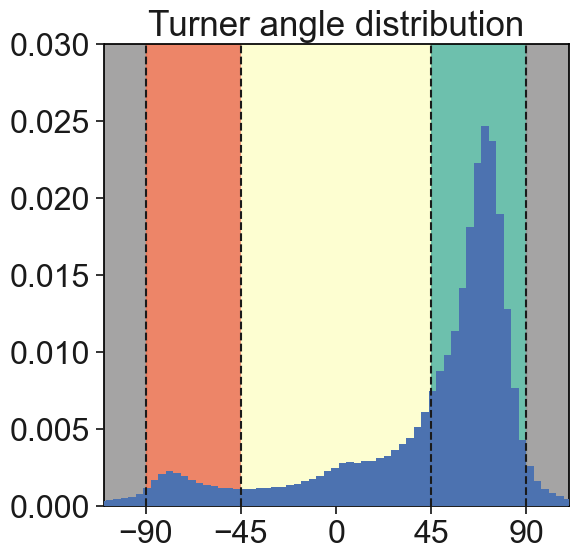

In [23]:
import matplotlib.patches as patches
Tu_bounds = [-120, -90, -45, 45, 90, 120]  # Extended limits for patching
colors = [
    cmo.gray.resampled(4)(2)[:3],     # Invalid
    cmo.matter.resampled(4)(1)[:3],  # Strong CD
    cmo.deep.resampled(4)(0)[:3],    # Stable
    cmo.deep.resampled(4)(1)[:3],    # Strong SF
    cmo.gray.resampled(4)(2)[:3]     # Invalid
]
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
# Plot background patches first
for i in range(len(colors)):
    ax.add_patch(patches.Rectangle((Tu_bounds[i], 0),Tu_bounds[i+1] - Tu_bounds[i],1.1,color=colors[i],alpha=0.9,zorder=0))
plt.title('Turner angle distribution')
_=plt.hist(d57.Tu.values.flatten(),color='b', bins=100,density=True,zorder=3)
ax.set_ylim(0, 0.03)  # Adjust based on your data
ax.set_xticks([-120, -90, -45, 0, 45, 90, 120])
#ax.set_xticklabels(['-120', '-90', '-60', '-45', '45', '60', '90', '120'], rotation=45)
plt.xlim(-110, 110)  # Reverse x-axis for better readability
plt.axvline(-45, color='k', linestyle='--',zorder=3)
plt.axvline(45, color='k', linestyle='--',zorder=3)
plt.axvline(-90, color='k', linestyle='--',zorder=3)
plt.axvline(90, color='k', linestyle='--',zorder=3)
#plt.savefig('Tu_distribution.png', dpi=600)

(-5.0, 10.0)

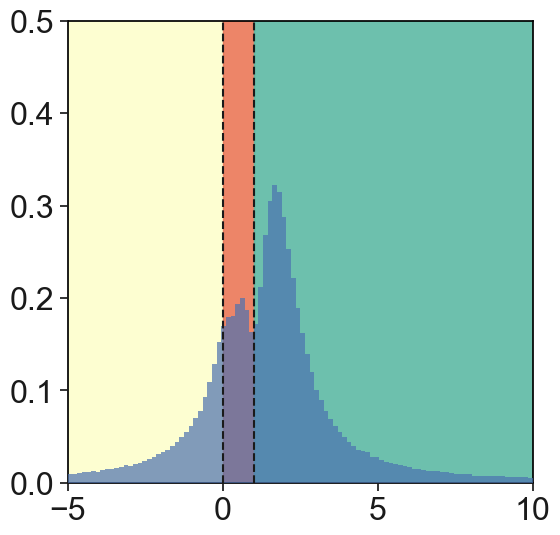

In [24]:
Rrho_bounds = [-5,0, 1,10]  # Extended limits for patching
colors = [
    cmo.deep.resampled(4)(0)[:3],    # Stable
    cmo.matter.resampled(4)(1)[:3],  # Strong CD
    cmo.deep.resampled(4)(1)[:3],    # Strong SF
]
fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
# Plot background patches first
for i in range(len(colors)):
    ax.add_patch(patches.Rectangle((Rrho_bounds[i], 0),Rrho_bounds[i+1] - Rrho_bounds[i],1.1,color=colors[i],alpha=0.9,zorder=0))
#plt.title('Turner angle distribution')
_=plt.hist(d57.Rrho.values.flatten(), bins=100, range=(-5,10),density=True,zorder=3,alpha=0.7)
ax.set_ylim(0, 0.5)  # Adjust based on your data
plt.axvline(0, color='k', linestyle='--',zorder=3)
plt.axvline(1, color='k', linestyle='--',zorder=3)
plt.xlim(-5, 10)  # Reverse x-axis for better readability

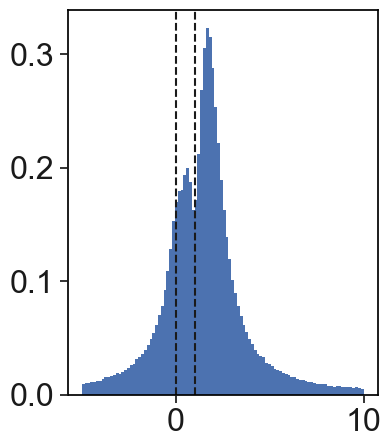

In [25]:
fig,ax=plt.subplots(1,1, figsize=(4, 5), dpi=100)
_=plt.hist(d57.Rrho.values.flatten(), bins=100, range=(-5,10),density=True)
plt.axvline(0, color='k', linestyle='--')
plt.axvline(1, color='k', linestyle='--')



In [26]:
d57["nu"] = (["depth", "time_profile"], nu.values)
d57["mu"] = (["depth", "time_profile"], mu.values)
d57["Reb"] = (["depth", "time_profile"], d57.epsi_QC_gm.values/(nu.values*d57.N2.values))

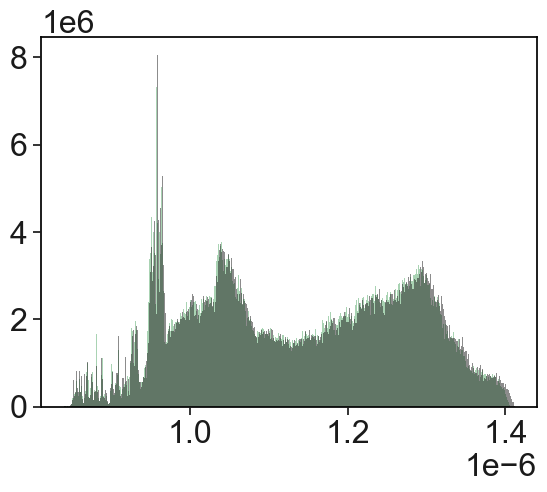

In [27]:
_=plt.hist(nu.values.flatten(), bins=1000, density=True, color='g', alpha=0.5)
_=plt.hist(nu2.values.flatten(), bins=1000, density=True, color='k', alpha=0.5)


In [28]:
d57_inrho=mapj.grid_in_rho(d57)
delta_rho=d57_inrho.density[1].values-d57_inrho.density[0].values
spiciness_curv=np.gradient(np.gradient((d57_inrho.spiciness.values),delta_rho,axis=0),delta_rho, axis=0)
d57_inrho = d57_inrho.assign({"spiciness_curvature" : (("density","time_profile"),spiciness_curv)})



Interpolating variables: 100%|██████████| 21/21 [00:07<00:00,  2.80it/s]


In [29]:
d57_inp=mapj.grid_in_P(d57_inrho, d57)
d57["spiciness_curvature"] =d57_inp.spiciness_curvature



Regridding to pressure grid: 100%|██████████| 20/20 [00:03<00:00,  5.64it/s]


In [30]:
anom_d57_inrho = (d57_inrho-d57_inrho.mean(dim="time_profile", skipna=True))
anom_d57_inp=mapj.grid_in_P(anom_d57_inrho, d57)


Regridding to pressure grid: 100%|██████████| 20/20 [00:03<00:00,  5.60it/s]


# COMPUTING MLD

In [31]:
ref_p=25

In [32]:
d57

<xarray.Dataset> Size: 384MB
Dimensions:                                (depth: 1026, time_profile: 709)
Coordinates:
  * depth                                  (depth) float64 8kB 0.0 ... 1.025e+03
    profile_index                          (time_profile) float64 6kB 1.0 ......
    time                                   (depth, time_profile) datetime64[ns] 6MB ...
  * time_profile                           (time_profile) datetime64[ns] 6kB ...
Data variables: (12/73)
    dive_num                               (depth, time_profile) float64 6MB ...
    conductivity                           (depth, time_profile) float64 6MB ...
    temperature                            (depth, time_profile) float64 6MB ...
    pressure                               (depth, time_profile) float64 6MB ...
    salinity                               (depth, time_profile) float64 6MB ...
    chlorophyll                            (depth, time_profile) float64 6MB ...
    ...                                     ...
    spiciness                              (depth, time_profile) float64 6MB ...
    Ri                                     (depth, time_profile) float64 6MB ...
    nu                                     (depth, time_profile) float64 6MB ...
    mu                                     (depth, time_profile) float64 6MB ...
    Reb                                    (depth, time_profile) float64 6MB ...
    spiciness_curvature                    (depth, time_profile) float64 6MB ...

In [33]:
mld = d57.where(((d57.potential_density-d57.sel(depth=ref_p, method='nearest').potential_density)>=0.125) & (d57.pressure>=ref_p)).pressure.min(dim='depth')
mld=mld.values
d57 = d57.assign({"mld" : (("time_profile"),mld)})

In [34]:
mld = d57.mld
# Convert to pandas Series for gap detection
s = mld.to_series()
# --- Step 1: identify short vs long gaps ---
# forward gap length (to next valid)
gap_fwd = (s.index.to_series().diff(-1).abs().shift(-1)).dt.total_seconds() / 3600
# backward gap length (to previous valid)
gap_bwd = (s.index.to_series().diff(1).abs()).dt.total_seconds() / 3600
# A point is in a short gap if both sides are < 8h
short_gap = (gap_fwd < 8) & (gap_bwd < 8)
short_gap = short_gap.fillna(False)
# --- Step 2: fill everything using ffill + bfill ---
s_filled = s.ffill().bfill()
# --- Step 3: restore NaNs in long gaps ---
s_final = s.where(~s.isna() | short_gap, np.nan)
s_final.loc[short_gap & s.isna()] = s_filled[short_gap & s.isna()]
# Convert back to DataArray
mld_filled = mld.copy(data=s_final.values)
d57 = d57.assign({"mld" : (("time_profile"),mld_filled.values)})

In [35]:
min_pressure=d57.where((d57.epsi_QC_gm > (1e-10)) & (d57.epsi_QC_gm < (1e-8))).pressure.min(dim='depth')
mld_e=min_pressure.values
#idx=mld_e>100
#mld_e[idx]=np.nan
#d57 = d57.assign({"mld_epsi" : (("distance"),mld_e)})

(300.0, 0.0)

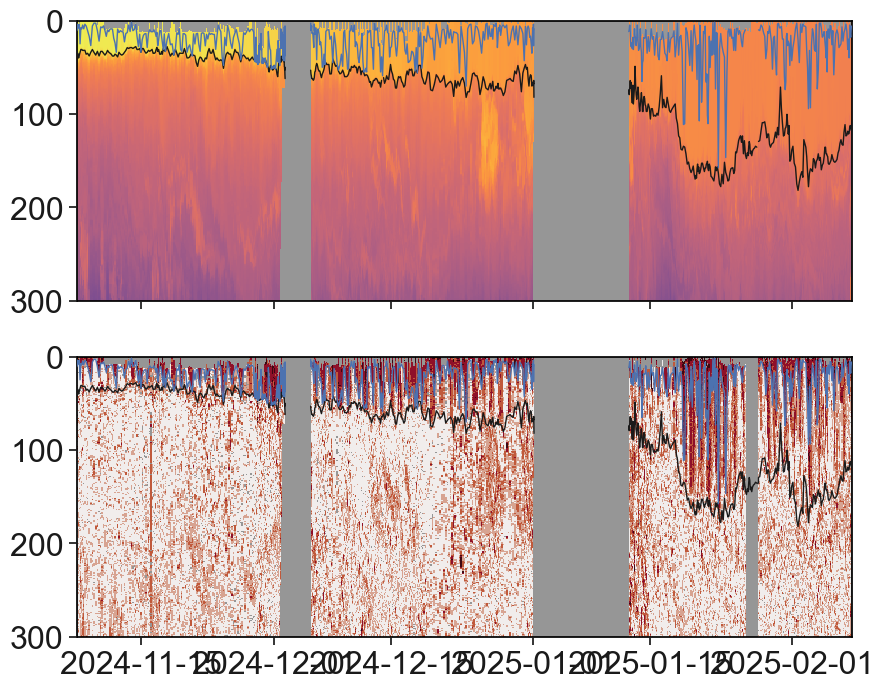

In [36]:
fig,axs=plt.subplots(2,1, figsize=(10, 8), dpi=100, sharex=True)
mesh=axs[0].pcolormesh(d57.time_profile,d57.depth, d57.cons_temperature, cmap='cmo.thermal', shading='auto')
axs[0].set_facecolor(np.array([1,1,1])/1.7)
axs[0].plot(d57.time_profile,mld, color='k', linewidth=1, label='MLD (Δρ>0.025 kg/m³)', zorder=3)
axs[0].plot(d57.time_profile,mld_e, color='b', linewidth=1, label='MLD (ε criteria)', zorder=3)
axs[0].set_ylim(300,0)

mesh=axs[1].pcolormesh(d57.time_profile,d57.depth, np.log10(d57.epsi_QC_gm),vmin=-10.5,vmax=-5.5,cmap =cmo.amp.resampled(5),zorder=1)
axs[1].set_facecolor(np.array([1,1,1])/1.7)
axs[1].plot(d57.time_profile,mld_filled, color='k', linewidth=1, label='MLD (Δρ>0.025 kg/m³)', zorder=3)
axs[1].plot(d57.time_profile,mld_e, color='b', linewidth=1, label='MLD (ε criteria)', zorder=3)
axs[1].set_ylim(300,0)

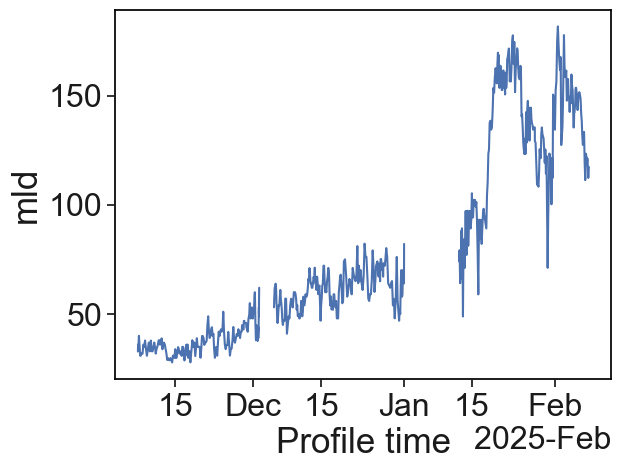

In [37]:
d57.mld.plot()

In [ ]:
# d57.to_netcdf('/Volumes/WD_BLACK/2024_OMAN/Data4Zenodo/SEA057_gridded_pprofile_processed.nc')
# anom_d57_inrho.to_netcdf('/Volumes/WD_BLACK/2024_OMAN/Data4Zenodo/SEA057_gridded_rho_anomalies.nc')
# anom_d57_inp.to_netcdf('/Volumes/WD_BLACK/2024_OMAN/Data4Zenodo/SEA057_gridded_p_anomalies.nc')
